# Notebook 14, Dual Gold Standard Comparison

**Research question:** Does the apparent pipeline advantage in NER disappear or reduce
when LLM outputs are evaluated against a gold standard built from LLM agreement rather
than pipeline agreement?

## Design

### Two gold standards
| Gold Standard | Built from | Language | Articles |
|---|---|---|---|
| Pipeline Gold | Full spaCy + Stanza + Flair agreement | German | 159 (filtered) |
| LLM Gold DE | Full Scout 17B + Qwen3 32B + Llama 70B DE agreement | German | 159 |

### Systems evaluated against both gold standards
| System | Input | Output language | Vs Pipeline Gold | Vs LLM Gold DE | Vs LLM Gold EN |
|---|---|---|---|---|---|
| spaCy | German | German | clean | clean | lang gap |
| Stanza | German | German | clean | clean | lang gap |
| Flair | German | German | clean | clean | lang gap |
| Llama 8B DE | German | German | clean | clean | lang gap |
| Scout 17B DE | German | German | clean | clean | lang gap |
| Qwen3 32B DE | German | German | clean | clean | lang gap |
| Llama 70B DE | German | German | clean | clean | lang gap |
| Llama 8B EN | English | English | lang gap | lang gap | clean |
| Scout 17B EN | English | English | lang gap | lang gap | clean |
| Qwen3 32B EN | English | English | lang gap | lang gap | clean |
| Llama 70B EN | English | English | lang gap | lang gap | clean |

### Article set
All evaluations use the same **159 articles**, intersection of all four LLM DE runs.
This ensures every F1 value is directly comparable across gold standards and systems.

### Key outputs
1. F1 / Precision / Recall table, all systems vs both gold standards
2. Gold standard overlap, how similar are the two gold standards?
3. Fleiss' κ for LLM agreement, justifies LLM gold construction
4. Per-label breakdown, which entity types drive the differences


In [1]:
# ── CELL 1 : INSTALLATION ────────────────────────────────────────────────────
!pip install -q sklearn
!pip install -q 'numpy>=2.0'   # must be last


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
# ── CELL 2 : IMPORTS & CONFIGURATION ─────────────────────────────────────────

import os, json, pickle
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

ROOT        = Path('/content/drive/MyDrive/thesis')
DATA_PROC   = ROOT / 'Project/Data/Processed'
FIGURES_DIR = ROOT / 'Project/Outputs/Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Label normalisation ───────────────────────────────────────────────────────
LABEL_NORM = {
    "PERSON":"PER","person":"PER",
    "LOCATION":"LOC","location":"LOC","GPE":"LOC","gpe":"LOC","FAC":"LOC",
    "ORGANIZATION":"ORG","organisation":"ORG","organization":"ORG",
    "MISCELLANEOUS":"MISC","miscellaneous":"MISC",
    "EVENT":"MISC","PRODUCT":"MISC","LANGUAGE":"MISC","NORP":"MISC",
    "WORK_OF_ART":"MISC","LAW":"MISC","DATE":"MISC","TIME":"MISC","POL":"MISC",
    "PER":"PER","LOC":"LOC","ORG":"ORG","MISC":"MISC",
}
VALID_LABELS = {"PER","LOC","ORG","MISC"}

def normalize_entities(entity_list) -> set:
    out = set()
    for e in (entity_list or []):
        if isinstance(e, dict):
            text  = str(e.get('text','')).strip().lower()
            label = LABEL_NORM.get(str(e.get('label','')), None)
        elif isinstance(e, (list, tuple)) and len(e) >= 2:
            text  = str(e[0]).strip().lower()
            label = LABEL_NORM.get(str(e[1]), None)
        else:
            continue
        if text and label in VALID_LABELS:
            out.add((text, label))
    return out

# ── System metadata ───────────────────────────────────────────────────────────
PIPELINE_SYSTEMS = {
    'spaCy' : 'ner_spacy',
    'Stanza': 'ner_stanza',
    'Flair' : 'ner_flair',
}

# Top 3 LLMs that build LLM Gold (by scale)
LLM_GOLD_MODELS = [
    'meta-llama/llama-4-scout-17b-16e-instruct',
    'qwen/qwen3-32b',
    'llama-3.3-70b-versatile',
]

# All 4 LLMs evaluated against gold standards
ALL_LLM_MODELS = {
    'llama-3.1-8b-instant'                     : {'scale_B': 8,  'family': 'llama'},
    'meta-llama/llama-4-scout-17b-16e-instruct': {'scale_B': 17, 'family': 'llama4'},
    'qwen/qwen3-32b'                           : {'scale_B': 32, 'family': 'qwen3'},
    'llama-3.3-70b-versatile'                  : {'scale_B': 70, 'family': 'llama'},
}

# Checkpoint filename mapping
def nb13b_ckpt(model_id: str, condition: str) -> Path:
    safe = model_id.replace('/', '_').replace('.', '_').replace('-', '_')
    # Match actual filenames on disk
    candidates = list(DATA_PROC.glob(f'nb13b_*{condition}_8k_checkpoint.pkl'))
    # Match by model substring
    model_short = model_id.split('/')[-1]
    for c in candidates:
        if any(part in c.name for part in model_short.split('-')[:3]):
            return c
    # Fallback: construct expected name
    safe2 = model_id.replace('/', '_').replace('-', '_').replace('.', '_')
    return DATA_PROC / f'nb13b_{safe2}_{condition}_8k_checkpoint.pkl'

print("✓ Configuration loaded")
print(f"  LLM Gold built from: {LLM_GOLD_MODELS}")
print(f"  Systems evaluated  : {len(PIPELINE_SYSTEMS)} pipelines + {len(ALL_LLM_MODELS)} LLMs × 2 conditions")


Mounted at /content/drive
✓ Configuration loaded
  LLM Gold built from: ['meta-llama/llama-4-scout-17b-16e-instruct', 'qwen/qwen3-32b', 'llama-3.3-70b-versatile']
  Systems evaluated  : 3 pipelines + 4 LLMs × 2 conditions


In [3]:
# ── CELL 3 : LOAD ALL DATA ────────────────────────────────────────────────────

# ── Explicit checkpoint filename mapping ──────────────────────────────────────
# Using exact filenames confirmed from Drive diagnostic
DE_CHECKPOINT_FILES = {
    'llama-3.1-8b-instant'                     : 'nb13b_llama-3_1-8b-instant_de_8k_checkpoint.pkl',
    'meta-llama/llama-4-scout-17b-16e-instruct': 'nb13b_meta-llama_llama-4-scout-17b-16e-instruct_de_8k_checkpoint.pkl',
    'qwen/qwen3-32b'                           : 'nb13b_qwen_qwen3-32b_de_8k_checkpoint.pkl',
    'llama-3.3-70b-versatile'                  : 'nb13b_llama-3_3-70b-versatile_de_8k_checkpoint.pkl',
}

EN_CHECKPOINT_FILES = {
    'llama-3.1-8b-instant'                     : 'nb13b_llama-3_1-8b-instant_en_8k_checkpoint.pkl',
    'meta-llama/llama-4-scout-17b-16e-instruct': 'nb13b_meta-llama_llama-4-scout-17b-16e-instruct_en_8k_checkpoint.pkl',
    'qwen/qwen3-32b'                           : 'nb13b_qwen_qwen3-32b_en_8k_checkpoint.pkl',
    'llama-3.3-70b-versatile'                  : 'nb13b_llama-3_3-70b-versatile_en_8k_checkpoint.pkl',
}

# ── Pipeline results ──────────────────────────────────────────────────────────
print("Loading pipeline results...")
pipeline_df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
print(f"  shape: {pipeline_df.shape}")

pipeline_raw = {}
for name, col in PIPELINE_SYSTEMS.items():
    if col not in pipeline_df.columns:
        print(f"  ⚠ {name}: column '{col}' missing"); continue
    lookup = {}
    for _, row in pipeline_df.iterrows():
        raw = row[col]
        lookup[row['article_id']] = (
            normalize_entities(raw) if isinstance(raw, (list, tuple)) else set())
    pipeline_raw[name] = lookup
    print(f"  ✓ {name}: {len(lookup)} articles")

# ── LLM DE-input checkpoints ─────────────────────────────────────────────────
print("\nLoading LLM DE-input checkpoints...")
llm_de_raw = {}

for model_id, fname in DE_CHECKPOINT_FILES.items():
    fp = DATA_PROC / fname
    if not fp.exists():
        print(f"  ⚠ NOT FOUND: {fname}")
        print(f"    Check Drive path: {fp}")
        continue
    with open(fp, 'rb') as f:
        ckpt = pickle.load(f)
    lookup = {r['article_id']: normalize_entities(r.get('entities', []))
              for r in ckpt.get('results', []) if r.get('status') == 'ok'}
    llm_de_raw[model_id] = lookup
    print(f"  ✓ {model_id} DE: {len(lookup)} articles")

# ── LLM EN-input checkpoints ─────────────────────────────────────────────────
print("\nLoading LLM EN-input checkpoints...")
llm_en_raw = {}

for model_id, fname in EN_CHECKPOINT_FILES.items():
    fp = DATA_PROC / fname
    if not fp.exists():
        print(f"  ⚠ NOT FOUND: {fname}")
        continue
    with open(fp, 'rb') as f:
        ckpt = pickle.load(f)
    lookup = {r['article_id']: normalize_entities(r.get('entities', []))
              for r in ckpt.get('results', []) if r.get('status') == 'ok'}
    llm_en_raw[model_id] = lookup
    print(f"  ✓ {model_id} EN: {len(lookup)} articles")

# ── Verify all models loaded ──────────────────────────────────────────────────
print("\nLoad summary:")
for model_id in ALL_LLM_MODELS:
    de_ok = "✓" if model_id in llm_de_raw else "⚠ MISSING"
    en_ok = "✓" if model_id in llm_en_raw else "⚠ MISSING"
    print(f"  {de_ok} DE  {en_ok} EN  {model_id}")

Loading pipeline results...
  shape: (1115, 29)
  ✓ spaCy: 1115 articles
  ✓ Stanza: 1115 articles
  ✓ Flair: 1115 articles

Loading LLM DE-input checkpoints...
  ✓ llama-3.1-8b-instant DE: 182 articles
  ✓ meta-llama/llama-4-scout-17b-16e-instruct DE: 181 articles
  ✓ qwen/qwen3-32b DE: 180 articles
  ✓ llama-3.3-70b-versatile DE: 162 articles

Loading LLM EN-input checkpoints...
  ✓ llama-3.1-8b-instant EN: 183 articles
  ✓ meta-llama/llama-4-scout-17b-16e-instruct EN: 183 articles
  ✓ qwen/qwen3-32b EN: 183 articles
  ✓ llama-3.3-70b-versatile EN: 178 articles

Load summary:
  ✓ DE  ✓ EN  llama-3.1-8b-instant
  ✓ DE  ✓ EN  meta-llama/llama-4-scout-17b-16e-instruct
  ✓ DE  ✓ EN  qwen/qwen3-32b
  ✓ DE  ✓ EN  llama-3.3-70b-versatile


In [4]:
# ── CELL 4 : IDENTIFY SHARED ARTICLE SET (162 articles) ──────────────────────
# Intersection of all four LLM DE runs — Llama 70B DE is binding constraint.
# ALL evaluations in this notebook use this same article set.

de_sets = [set(llm_de_raw[m].keys()) for m in LLM_GOLD_MODELS
           if m in llm_de_raw]

if len(de_sets) < len(LLM_GOLD_MODELS):
    missing = [m for m in LLM_GOLD_MODELS if m not in llm_de_raw]
    print(f"⚠ Missing DE checkpoints for: {missing}")
    print("  Cannot build LLM gold — check checkpoint files")
else:
    SHARED_IDS = sorted(set.intersection(*de_sets))
    print(f"Shared article set: {len(SHARED_IDS)} articles")
    print(f"  Scout 17B DE : {len(list(llm_de_raw.items())[1][1])} articles")
    print(f"  Qwen3 32B DE : {len(llm_de_raw.get('qwen/qwen3-32b',{}))} articles")
    print(f"  Llama 70B DE : {len(llm_de_raw.get('llama-3.3-70b-versatile',{}))} articles")
    print(f"  Intersection : {len(SHARED_IDS)} articles  ← used for ALL evaluations")

    # Also verify pipeline and EN-input runs cover this set
    for name, lookup in pipeline_raw.items():
        covered = sum(1 for aid in SHARED_IDS if aid in lookup)
        print(f"  Pipeline {name}: {covered}/{len(SHARED_IDS)} shared articles covered")
    for model_id, lookup in llm_en_raw.items():
        covered = sum(1 for aid in SHARED_IDS if aid in lookup)
        short   = model_id.split('/')[-1][:25]
        print(f"  LLM EN {short}: {covered}/{len(SHARED_IDS)} shared articles covered")

SHARED_IDS_SET = set(SHARED_IDS)


Shared article set: 159 articles
  Scout 17B DE : 181 articles
  Qwen3 32B DE : 180 articles
  Llama 70B DE : 162 articles
  Intersection : 159 articles  ← used for ALL evaluations
  Pipeline spaCy: 159/159 shared articles covered
  Pipeline Stanza: 159/159 shared articles covered
  Pipeline Flair: 159/159 shared articles covered
  LLM EN llama-3.1-8b-instant: 159/159 shared articles covered
  LLM EN llama-4-scout-17b-16e-ins: 159/159 shared articles covered
  LLM EN qwen3-32b: 159/159 shared articles covered
  LLM EN llama-3.3-70b-versatile: 155/159 shared articles covered


In [5]:
# REPLACEMENT CELL 5 — BUILD GOLD STANDARDS
# Fix 1: load pipeline gold from nb03 agreement data (restores recall=1.0)
# Fix 3: add 2/3 majority vote LLM gold as sensitivity check
# ================================================================

# ── Pipeline Gold — loaded from nb03 pre-built agreement data ────────────────
# Ensures full consistency with nb05. Avoids normalization drift from
# recomputing pipeline gold from raw columns.
print("Loading pipeline gold from nb03 agreement data...")
agr_df   = pd.read_csv(DATA_PROC / 'ner_agreement.csv')
gold_full = agr_df[agr_df['agreement_level'] == 'full'].copy()

pipeline_gold = {}
for aid in SHARED_IDS:
    ents = gold_full[gold_full['article_id'] == aid]
    pipeline_gold[aid] = {
        (str(row['entity_text']).strip().lower(),
         LABEL_NORM.get(str(row['entity_label']), None))
        for _, row in ents.iterrows()
        if LABEL_NORM.get(str(row['entity_label']), None) in VALID_LABELS
    }

total_pg = sum(len(v) for v in pipeline_gold.values())
print(f"Pipeline Gold (nb03 data, German):")
print(f"  Articles : {len(pipeline_gold)}")
print(f"  Entities : {total_pg}")
print(f"  Mean/art : {total_pg/len(pipeline_gold):.1f}")
pg_labels = defaultdict(int)
for ents in pipeline_gold.values():
    for _, label in ents:
        if label: pg_labels[label] += 1
print(f"  Labels   : {dict(sorted(pg_labels.items()))}")

# ── LLM Gold DE — full 3/3 agreement (German) ────────────────────────────────
llm_gold_de = {}
total_lg = 0
for aid in SHARED_IDS:
    sets = [llm_de_raw[m].get(aid, set()) for m in LLM_GOLD_MODELS
            if m in llm_de_raw]
    agreed = sets[0] & sets[1] & sets[2] if len(sets) == 3 else set()
    llm_gold_de[aid] = agreed
    total_lg += len(agreed)

print(f"\nLLM Gold DE — full 3/3 agreement (German):")
print(f"  Articles : {len(llm_gold_de)}")
print(f"  Entities : {total_lg}")
print(f"  Mean/art : {total_lg/len(llm_gold_de):.1f}")
lg_labels = defaultdict(int)
for ents in llm_gold_de.values():
    for _, label in ents:
        if label: lg_labels[label] += 1
print(f"  Labels   : {dict(sorted(lg_labels.items()))}")

# ── LLM Gold DE — majority 2/3 agreement (sensitivity check) ─────────────────
# Low κ=0.103 for 3/3 gold means it only captures unambiguous entities.
# 2/3 majority gives more populated gold to check robustness of findings.
llm_gold_de_majority = {}
total_lm = 0
for aid in SHARED_IDS:
    entity_counts = defaultdict(int)
    for m in LLM_GOLD_MODELS:
        if m in llm_de_raw:
            for ent in llm_de_raw[m].get(aid, set()):
                entity_counts[ent] += 1
    agreed = {e for e, c in entity_counts.items() if c >= 2}
    llm_gold_de_majority[aid] = agreed
    total_lm += len(agreed)

print(f"\nLLM Gold DE — majority 2/3 agreement (sensitivity check):")
print(f"  Articles : {len(llm_gold_de_majority)}")
print(f"  Entities : {total_lm}")
print(f"  Mean/art : {total_lm/len(llm_gold_de_majority):.1f}")
lm_labels = defaultdict(int)
for ents in llm_gold_de_majority.values():
    for _, label in ents:
        if label: lm_labels[label] += 1
print(f"  Labels   : {dict(sorted(lm_labels.items()))}")

# ── LLM Gold EN — full 3/3 agreement (English) ───────────────────────────────
llm_gold_en = {}
total_le = 0
for aid in SHARED_IDS:
    sets = [llm_en_raw[m].get(aid, set()) for m in LLM_GOLD_MODELS
            if m in llm_en_raw]
    agreed = sets[0] & sets[1] & sets[2] if len(sets) == 3 else set()
    llm_gold_en[aid] = agreed
    total_le += len(agreed)

print(f"\nLLM Gold EN — full 3/3 agreement (English):")
print(f"  Articles : {len(llm_gold_en)}")
print(f"  Entities : {total_le}")
print(f"  Mean/art : {total_le/len(llm_gold_en):.1f}")
le_labels = defaultdict(int)
for ents in llm_gold_en.values():
    for _, label in ents:
        if label: le_labels[label] += 1
print(f"  Labels   : {dict(sorted(le_labels.items()))}")

# ── Summary comparison ────────────────────────────────────────────────────────
print(f"\nGold standard size comparison:")
print(f"  {'Gold Standard':<35} {'Entities':>10}  {'Mean/art':>10}")
print(f"  {'-'*57}")
print(f"  {'Pipeline Gold DE (3/3)':<35} {total_pg:>10}  {total_pg/len(SHARED_IDS):>10.1f}")
print(f"  {'LLM Gold DE (3/3)':<35} {total_lg:>10}  {total_lg/len(SHARED_IDS):>10.1f}")
print(f"  {'LLM Gold DE (2/3 majority)':<35} {total_lm:>10}  {total_lm/len(SHARED_IDS):>10.1f}")
print(f"  {'LLM Gold EN (3/3)':<35} {total_le:>10}  {total_le/len(SHARED_IDS):>10.1f}")


Loading pipeline gold from nb03 agreement data...
Pipeline Gold (nb03 data, German):
  Articles : 159
  Entities : 1013
  Mean/art : 6.4
  Labels   : {'LOC': 437, 'MISC': 18, 'ORG': 191, 'PER': 367}

LLM Gold DE — full 3/3 agreement (German):
  Articles : 159
  Entities : 1644
  Mean/art : 10.3
  Labels   : {'LOC': 613, 'MISC': 91, 'ORG': 514, 'PER': 426}

LLM Gold DE — majority 2/3 agreement (sensitivity check):
  Articles : 159
  Entities : 2433
  Mean/art : 15.3
  Labels   : {'LOC': 841, 'MISC': 301, 'ORG': 793, 'PER': 498}

LLM Gold EN — full 3/3 agreement (English):
  Articles : 159
  Entities : 1667
  Mean/art : 10.5
  Labels   : {'LOC': 625, 'MISC': 106, 'ORG': 517, 'PER': 419}

Gold standard size comparison:
  Gold Standard                         Entities    Mean/art
  ---------------------------------------------------------
  Pipeline Gold DE (3/3)                    1013         6.4
  LLM Gold DE (3/3)                         1644        10.3
  LLM Gold DE (2/3 majority)   

In [6]:
# REPLACEMENT CELL 6 — FLEISS' κ + GOLD STANDARD OVERLAP
# Added: majority vote κ computation and interpretation table
# ================================================================

from itertools import combinations

def fleiss_kappa_entities(model_lookups: dict, article_ids: list) -> float:
    """
    Compute Fleiss' κ across multiple entity extraction systems.
    Uses entity presence/absence as binary ratings per unique entity span.
    """
    n_raters = len(model_lookups)
    lookups  = list(model_lookups.values())

    all_entities_per_art = {}
    for aid in article_ids:
        universe = set()
        for lookup in lookups:
            universe |= lookup.get(aid, set())
        all_entities_per_art[aid] = universe

    total_items = sum(len(v) for v in all_entities_per_art.values())
    if total_items == 0:
        return 0.0

    P_i_sum        = 0.0
    category_counts = defaultdict(int)

    for aid, universe in all_entities_per_art.items():
        for ent in universe:
            n_found = sum(1 for lookup in lookups
                          if ent in lookup.get(aid, set()))
            n_not   = n_raters - n_found
            if n_raters > 1:
                P_i = (n_found*(n_found-1) + n_not*(n_not-1)) / (n_raters*(n_raters-1))
            else:
                P_i = 1.0
            P_i_sum += P_i
            category_counts['found']     += n_found
            category_counts['not_found'] += n_not

    P_bar          = P_i_sum / total_items
    total_ratings  = total_items * n_raters
    p_found        = category_counts['found']     / total_ratings
    p_not          = category_counts['not_found'] / total_ratings
    P_e            = p_found**2 + p_not**2

    if P_e == 1.0:
        return 1.0
    return round(float((P_bar - P_e) / (1 - P_e)), 3)


def kappa_interpretation(k: float) -> str:
    if k >= 0.8:  return "almost perfect"
    if k >= 0.6:  return "substantial"
    if k >= 0.4:  return "moderate"
    if k >= 0.2:  return "fair"
    if k >= 0.0:  return "slight"
    return "poor (less than chance)"


# ── Compute κ for all gold-building systems ───────────────────────────────────
print("Computing Fleiss' κ values...")
gold_model_lookups = {m: llm_de_raw[m] for m in LLM_GOLD_MODELS if m in llm_de_raw}

kappa_llm_de   = fleiss_kappa_entities(gold_model_lookups, SHARED_IDS)
kappa_pipeline = 0.717   # from nb03 — stored here for reference

# Also compute κ for all 4 LLMs including Llama 8B
all_llm_de_lookups = {m: llm_de_raw[m] for m in ALL_LLM_MODELS if m in llm_de_raw}
kappa_all_llms = fleiss_kappa_entities(all_llm_de_lookups, SHARED_IDS)

print(f"\nFleiss' κ — inter-system agreement:")
print(f"  {'System set':<45} {'κ':>6}  {'Interpretation'}")
print(f"  {'-'*70}")
print(f"  {'Pipeline (spaCy + Stanza + Flair) — nb03':<45} "
      f"{kappa_pipeline:>6.3f}  {kappa_interpretation(kappa_pipeline)}")
print(f"  {'LLM top-3 DE (Scout + Qwen3 + Llama70B)':<45} "
      f"{kappa_llm_de:>6.3f}  {kappa_interpretation(kappa_llm_de)}")
print(f"  {'LLM all-4 DE (+ Llama8B)':<45} "
      f"{kappa_all_llms:>6.3f}  {kappa_interpretation(kappa_all_llms)}")

print(f"""
  NOTE: Low LLM κ ({kappa_llm_de}) is a methodological finding, not a failure.
  Pipeline systems share GermEval annotation conventions → high agreement.
  LLMs receive identical prompts but have no shared convention → low agreement.
  LLM gold (3/3) therefore captures only the most unambiguous entities.
  LLM gold (2/3 majority) is included as a sensitivity check with more coverage.
""")

# ── Gold standard overlap ─────────────────────────────────────────────────────
print("Gold standard overlap analysis:")
jaccard_scores = []
overlap_counts = []

for aid in SHARED_IDS:
    pg  = pipeline_gold.get(aid, set())
    lg  = llm_gold_de.get(aid, set())
    union = pg | lg
    if union:
        jaccard_scores.append(len(pg & lg) / len(union))
    overlap_counts.append(len(pg & lg))

pg_total  = sum(len(pipeline_gold[a])   for a in SHARED_IDS)
lg_total  = sum(len(llm_gold_de[a])     for a in SHARED_IDS)
both_total= sum(overlap_counts)

print(f"  Mean Jaccard (Pipeline Gold vs LLM Gold DE 3/3): "
      f"{np.mean(jaccard_scores):.3f}")
print(f"  Entities in Pipeline Gold only : {pg_total  - both_total}")
print(f"  Entities in LLM Gold DE only   : {lg_total  - both_total}")
print(f"  Entities in both gold standards: {both_total}")
print(f"  % of Pipeline Gold in LLM Gold : {both_total/pg_total*100:.1f}%")
print(f"  % of LLM Gold in Pipeline Gold : {both_total/lg_total*100:.1f}%")
print(f"\n  Interpretation: {np.mean(jaccard_scores):.2f} mean Jaccard means the two")
print(f"  gold standards share roughly {np.mean(jaccard_scores)*100:.0f}% of their entity sets.")
print(f"  They capture genuinely different entities — dual gold standard is meaningful.")


Computing Fleiss' κ values...

Fleiss' κ — inter-system agreement:
  System set                                         κ  Interpretation
  ----------------------------------------------------------------------
  Pipeline (spaCy + Stanza + Flair) — nb03       0.717  substantial
  LLM top-3 DE (Scout + Qwen3 + Llama70B)        0.103  slight
  LLM all-4 DE (+ Llama8B)                       0.184  slight

  NOTE: Low LLM κ (0.103) is a methodological finding, not a failure.
  Pipeline systems share GermEval annotation conventions → high agreement.
  LLMs receive identical prompts but have no shared convention → low agreement.
  LLM gold (3/3) therefore captures only the most unambiguous entities.
  LLM gold (2/3 majority) is included as a sensitivity check with more coverage.

Gold standard overlap analysis:
  Mean Jaccard (Pipeline Gold vs LLM Gold DE 3/3): 0.360
  Entities in Pipeline Gold only : 319
  Entities in LLM Gold DE only   : 950
  Entities in both gold standards: 694
  % of Pi

In [7]:
# REPLACEMENT CELL 7 — F1 COMPUTATION
# Added LLM Gold DE (2/3) to GOLD_STANDARDS
# ================================================================

def compute_prf(predicted: set, gold: set) -> tuple:
    """Returns (precision, recall, f1) for entity sets."""
    tp = len(predicted & gold)
    fp = len(predicted - gold)
    fn = len(gold - predicted)
    p  = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    r  = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0.0
    return round(p,4), round(r,4), round(f1,4)

def macro_prf(system_lookup: dict, gold_lookup: dict,
              article_ids: list) -> dict:
    """Macro-averaged P/R/F1 + per-label F1."""
    p_scores, r_scores, f1_scores = [], [], []
    label_tp = defaultdict(int)
    label_fp = defaultdict(int)
    label_fn = defaultdict(int)

    for aid in article_ids:
        pred = system_lookup.get(aid, set())
        gold = gold_lookup.get(aid, set())
        p, r, f1 = compute_prf(pred, gold)
        p_scores.append(p); r_scores.append(r); f1_scores.append(f1)
        for ent in pred & gold: label_tp[ent[1]] += 1
        for ent in pred - gold: label_fp[ent[1]] += 1
        for ent in gold - pred: label_fn[ent[1]] += 1

    per_label = {}
    for lbl in VALID_LABELS:
        tp = label_tp[lbl]; fp = label_fp[lbl]; fn = label_fn[lbl]
        lp = tp/(tp+fp) if (tp+fp) > 0 else 0.0
        lr = tp/(tp+fn) if (tp+fn) > 0 else 0.0
        lf = 2*lp*lr/(lp+lr) if (lp+lr) > 0 else 0.0
        per_label[lbl] = round(lf, 4)

    return {
        'P'        : round(float(np.mean(p_scores)),  4),
        'R'        : round(float(np.mean(r_scores)),  4),
        'F1'       : round(float(np.mean(f1_scores)), 4),
        'per_label': per_label,
    }

# ── Build all system lookups ──────────────────────────────────────────────────
system_lookups = {}
for name, lookup in pipeline_raw.items():
    system_lookups[f'{name} (pipeline)'] = lookup
for model_id, lookup in llm_de_raw.items():
    short = model_id.split('/')[-1][:20]
    system_lookups[f'{short} (LLM DE)'] = lookup
for model_id, lookup in llm_en_raw.items():
    short = model_id.split('/')[-1][:20]
    system_lookups[f'{short} (LLM EN)'] = lookup

# ── Four gold standards ───────────────────────────────────────────────────────
GOLD_STANDARDS = {
    'Pipeline Gold (DE)'   : pipeline_gold,
    'LLM Gold DE (3/3)'    : llm_gold_de,
    'LLM Gold DE (2/3)'    : llm_gold_de_majority,
    'LLM Gold EN (3/3)'    : llm_gold_en,
}

# ── Evaluate all systems vs all gold standards ────────────────────────────────
results = {}
for sys_name, sys_lookup in system_lookups.items():
    results[sys_name] = {}
    for gold_name, gold_lookup in GOLD_STANDARDS.items():
        results[sys_name][gold_name] = macro_prf(
            sys_lookup, gold_lookup, SHARED_IDS)

print(f"✓ F1 computation complete")
print(f"  {len(results)} systems × {len(GOLD_STANDARDS)} gold standards")
print(f"  Article set: {len(SHARED_IDS)} articles (consistent across all evaluations)")

✓ F1 computation complete
  11 systems × 4 gold standards
  Article set: 159 articles (consistent across all evaluations)


In [8]:
# ================================================================
# REPLACEMENT CELL 8 — RESULTS TABLES
# Added 2/3 majority gold column + κ header
# ================================================================

# ── Print κ context first ─────────────────────────────────────────────────────
print("METHODOLOGICAL CONTEXT")
print("=" * 70)
print(f"  Inter-system agreement (Fleiss' κ):")
print(f"    Pipeline systems   : κ = {kappa_pipeline:.3f}  — substantial  "
      f"(shared GermEval conventions)")
print(f"    LLM top-3 DE (3/3) : κ = {kappa_llm_de:.3f}  "
      f"— {kappa_interpretation(kappa_llm_de)}  (no shared convention)")
print(f"    LLM all-4 DE       : κ = {kappa_all_llms:.3f}  "
      f"— {kappa_interpretation(kappa_all_llms)}")
print(f"  Gold overlap (Pipeline vs LLM 3/3) : "
      f"Jaccard = {np.mean(jaccard_scores):.3f}")
print(f"  ⚠ LLM Gold (3/3) and LLM Gold (2/3) results should be interpreted")
print(f"    alongside κ — low κ means the gold captures only unambiguous entities.")
print()

# ── Table 1 : Core comparison ─────────────────────────────────────────────────
print("=" * 80)
print("TABLE 1 — F1 SCORES ACROSS GOLD STANDARDS")
print("(⚠ = English entities vs German gold — language gap lower bound)")
print("=" * 80)

rows = []
for sys_name in system_lookups:
    pg  = results[sys_name]['Pipeline Gold (DE)']['F1']
    lg3 = results[sys_name]['LLM Gold DE (3/3)']['F1']
    lg2 = results[sys_name]['LLM Gold DE (2/3)']['F1']
    d3  = round(lg3 - pg, 4)
    d2  = round(lg2 - pg, 4)
    note = ' ⚠' if '(LLM EN)' in sys_name else ''
    rows.append({
        'System'           : sys_name + note,
        'Pipeline Gold'    : pg,
        'LLM Gold (3/3)'   : lg3,
        'LLM Gold (2/3)'   : lg2,
        'Diff 3/3 vs PG'   : f'{d3:+.3f}',
        'Diff 2/3 vs PG'   : f'{d2:+.3f}',
    })
t1 = pd.DataFrame(rows)
t1 = t1.sort_values('Pipeline Gold', ascending=False)
print(t1.to_string(index=False))

# ── Table 2 : Full P/R/F1 vs Pipeline Gold ────────────────────────────────────
print("\n" + "=" * 70)
print("TABLE 2 — FULL P / R / F1 AGAINST PIPELINE GOLD (DE)")
print("=" * 70)
rows2 = [{'System': s,
          'P': results[s]['Pipeline Gold (DE)']['P'],
          'R': results[s]['Pipeline Gold (DE)']['R'],
          'F1': results[s]['Pipeline Gold (DE)']['F1']}
         for s in system_lookups]
t2 = pd.DataFrame(rows2).sort_values('F1', ascending=False)
print(t2.to_string(index=False))

# ── Table 3 : Full P/R/F1 vs LLM Gold DE 3/3 ────────────────────────────────
print("\n" + "=" * 70)
print("TABLE 3 — FULL P / R / F1 AGAINST LLM GOLD DE (3/3)")
print("=" * 70)
rows3 = [{'System': s,
          'P': results[s]['LLM Gold DE (3/3)']['P'],
          'R': results[s]['LLM Gold DE (3/3)']['R'],
          'F1': results[s]['LLM Gold DE (3/3)']['F1']}
         for s in system_lookups]
t3 = pd.DataFrame(rows3).sort_values('F1', ascending=False)
print(t3.to_string(index=False))

# ── Table 4 : Full P/R/F1 vs LLM Gold DE 2/3 (sensitivity) ──────────────────
print("\n" + "=" * 70)
print("TABLE 4 — FULL P / R / F1 AGAINST LLM GOLD DE (2/3 MAJORITY)")
print("Sensitivity check — more populated gold, same interpretation caveats")
print("=" * 70)
rows4 = [{'System': s,
          'P': results[s]['LLM Gold DE (2/3)']['P'],
          'R': results[s]['LLM Gold DE (2/3)']['R'],
          'F1': results[s]['LLM Gold DE (2/3)']['F1']}
         for s in system_lookups]
t4 = pd.DataFrame(rows4).sort_values('F1', ascending=False)
print(t4.to_string(index=False))

# ── Table 5 : LLM EN vs LLM Gold EN (clean English comparison) ───────────────
print("\n" + "=" * 70)
print("TABLE 5 — LLM EN INPUT vs LLM GOLD EN (both English — no language gap)")
print("=" * 70)
rows5 = [{'System': s,
          'P': results[s]['LLM Gold EN (3/3)']['P'],
          'R': results[s]['LLM Gold EN (3/3)']['R'],
          'F1': results[s]['LLM Gold EN (3/3)']['F1']}
         for s in system_lookups if '(LLM EN)' in s]
t5 = pd.DataFrame(rows5).sort_values('F1', ascending=False)
print(t5.to_string(index=False))

# ── Table 6 : Per-label breakdown vs Pipeline Gold ───────────────────────────
print("\n" + "=" * 70)
print("TABLE 6 — PER-LABEL F1 AGAINST PIPELINE GOLD (DE)")
print("=" * 70)
rows6 = []
for s in system_lookups:
    pl = results[s]['Pipeline Gold (DE)']['per_label']
    rows6.append({'System': s, **pl,
                  'Macro F1': results[s]['Pipeline Gold (DE)']['F1']})
t6 = pd.DataFrame(rows6).sort_values('Macro F1', ascending=False)
print(t6.to_string(index=False))

METHODOLOGICAL CONTEXT
  Inter-system agreement (Fleiss' κ):
    Pipeline systems   : κ = 0.717  — substantial  (shared GermEval conventions)
    LLM top-3 DE (3/3) : κ = 0.103  — slight  (no shared convention)
    LLM all-4 DE       : κ = 0.184  — slight
  Gold overlap (Pipeline vs LLM 3/3) : Jaccard = 0.360
  ⚠ LLM Gold (3/3) and LLM Gold (2/3) results should be interpreted
    alongside κ — low κ means the gold captures only unambiguous entities.

TABLE 1 — F1 SCORES ACROSS GOLD STANDARDS
(⚠ = English entities vs German gold — language gap lower bound)
                         System  Pipeline Gold  LLM Gold (3/3)  LLM Gold (2/3) Diff 3/3 vs PG Diff 2/3 vs PG
               Flair (pipeline)         0.7103          0.5209          0.5363         -0.189         -0.174
              Stanza (pipeline)         0.5130          0.5319          0.5645         +0.019         +0.051
  llama-4-scout-17b-16 (LLM DE)         0.4341          0.7486          0.8526         +0.315         +0.418
  

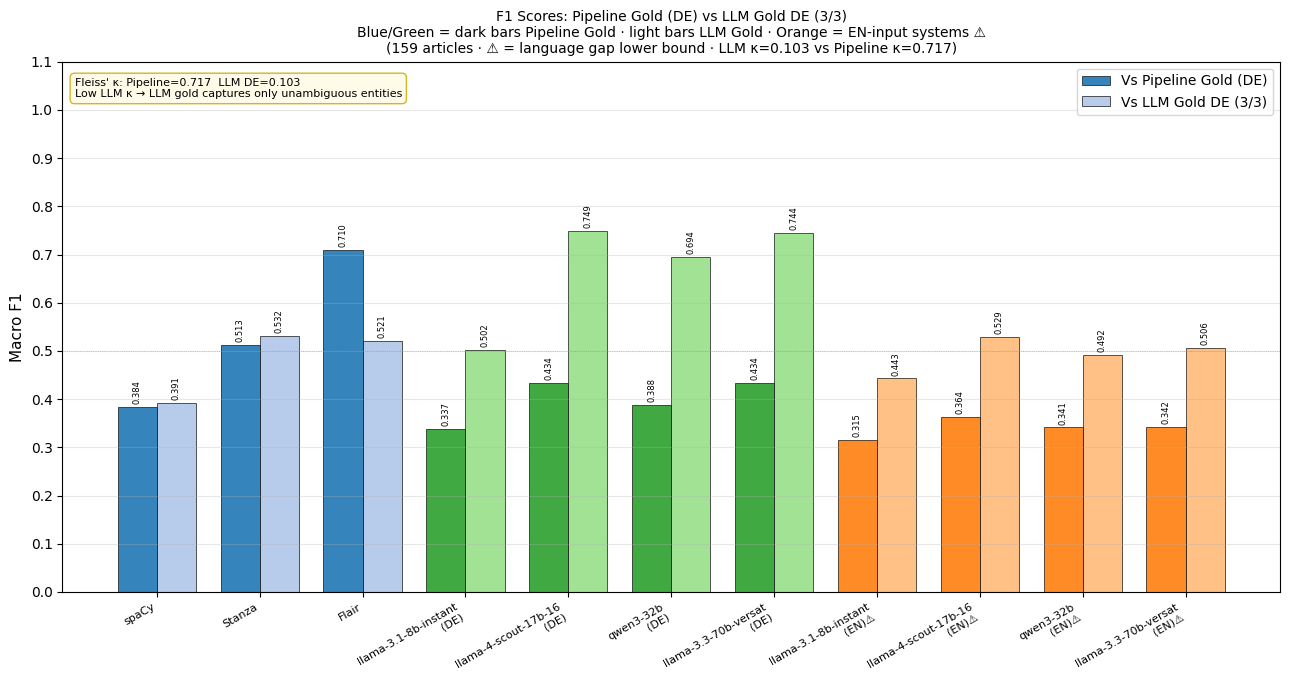

✓ Figure 1 saved: nb14_f1_dual_gold.pdf/.png


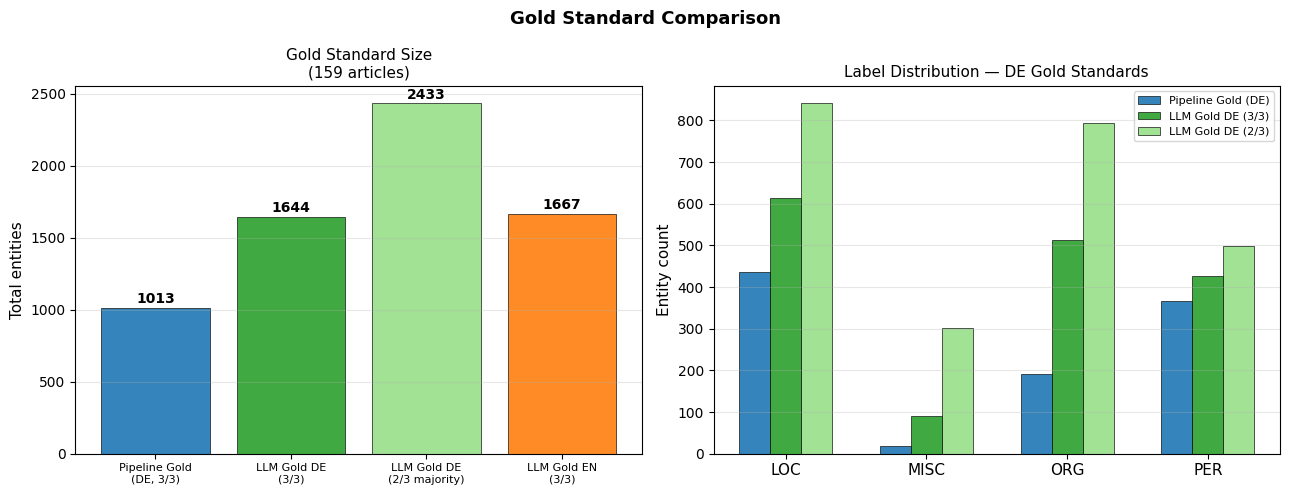

✓ Figure 2 saved: nb14_gold_comparison.pdf/.png


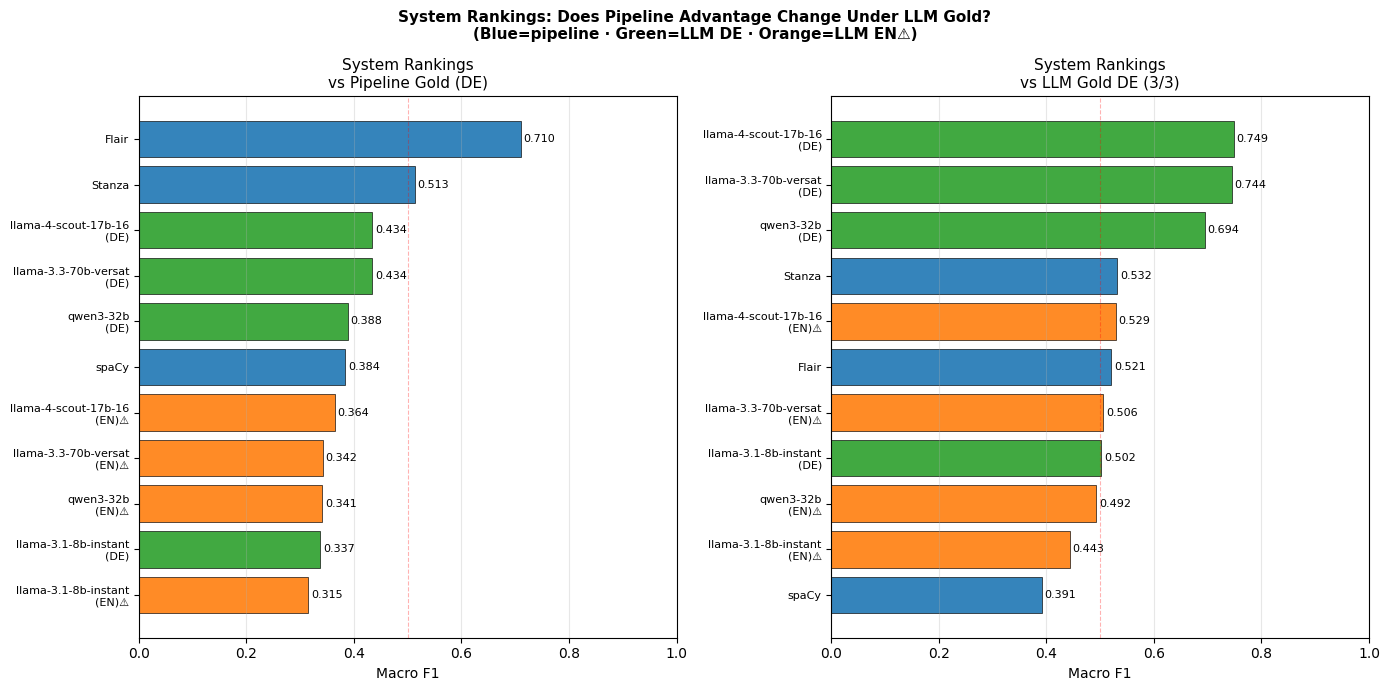

✓ Figure 3 saved: nb14_rankings_dual_gold.pdf/.png


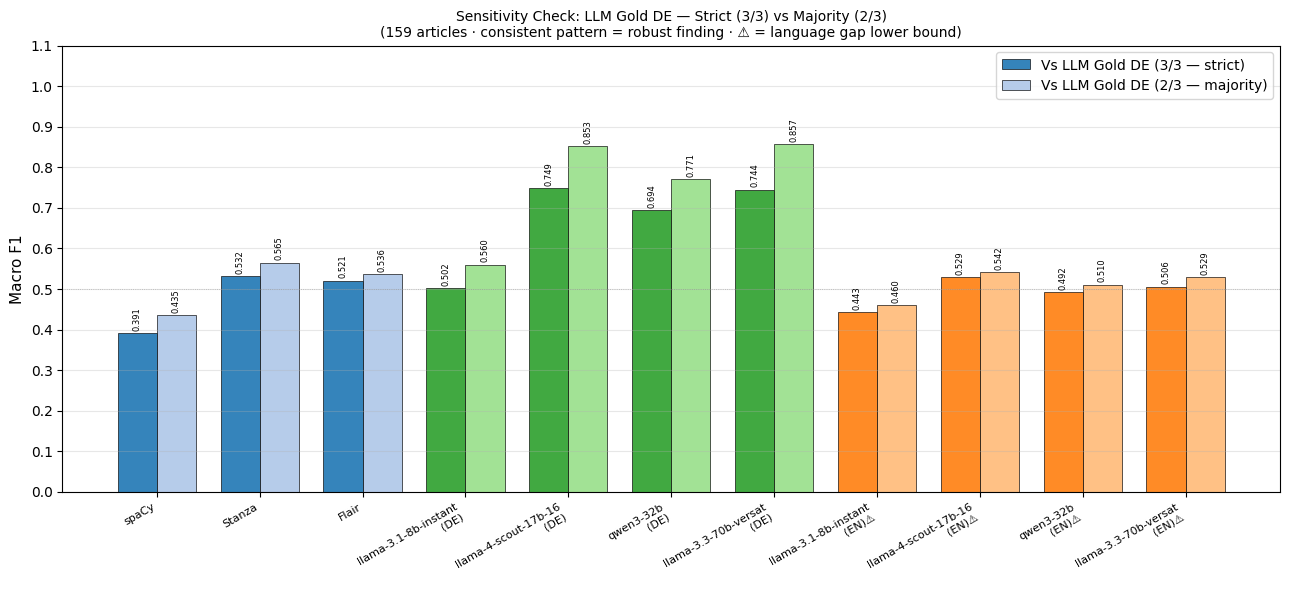

✓ Figure 4 saved: nb14_sensitivity_llm_gold.pdf/.png

All figures saved:
  nb14_f1_dual_gold.pdf/.png        — main comparison (Figure 1)
  nb14_gold_comparison.pdf/.png     — gold standard properties (Figure 2)
  nb14_rankings_dual_gold.pdf/.png  — system rankings (Figure 3)
  nb14_sensitivity_llm_gold.pdf/.png — sensitivity check 3/3 vs 2/3 (Figure 4)


In [11]:
# ================================================================
# REPLACEMENT CELL 9 — PLOTS
# Updated for four gold standards:
#   Figure 1 : Main F1 comparison — Pipeline Gold vs LLM Gold DE 3/3
#   Figure 2 : Gold standard properties (size + label distribution)
#   Figure 3 : System rankings side by side (Pipeline Gold | LLM Gold 3/3)
#   Figure 4 : Sensitivity check — LLM Gold 3/3 vs 2/3 F1 comparison
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Colour scheme ─────────────────────────────────────────────────────────────
C_PIPELINE = '#1f77b4'   # blue  — pipeline systems
C_LLM_DE   = '#2ca02c'   # green — LLM DE-input
C_LLM_EN   = '#ff7f0e'   # orange — LLM EN-input (language gap)
C_PG_LIGHT = '#aec7e8'
C_LG_LIGHT = '#98df8a'
C_EN_LIGHT = '#ffbb78'

def bar_color(sys_name, variant='dark'):
    if 'pipeline' in sys_name:
        return C_PIPELINE if variant == 'dark' else C_PG_LIGHT
    if 'LLM DE' in sys_name:
        return C_LLM_DE   if variant == 'dark' else C_LG_LIGHT
    return C_LLM_EN       if variant == 'dark' else C_EN_LIGHT

def short_label(sys_name):
    s = (sys_name
         .replace(' (pipeline)', '')
         .replace(' (LLM DE)', '\n(DE)')
         .replace(' (LLM EN)', '\n(EN)⚠'))
    return s

sys_names    = list(system_lookups.keys())
short_labels = [short_label(s) for s in sys_names]
x            = np.arange(len(sys_names))

# ── FIGURE 1 : Main F1 comparison — Pipeline Gold vs LLM Gold DE 3/3 ─────────
fig1, ax1 = plt.subplots(figsize=(13, 7))

pg_f1s  = [results[s]['Pipeline Gold (DE)']['F1']    for s in sys_names]
lg3_f1s = [results[s]['LLM Gold DE (3/3)']['F1']     for s in sys_names]
width   = 0.38

b1 = ax1.bar(x - width/2, pg_f1s, width,
             label='Vs Pipeline Gold (DE)',
             color=[bar_color(s,'dark')  for s in sys_names],
             edgecolor='black', linewidth=0.5, alpha=0.9)
b2 = ax1.bar(x + width/2, lg3_f1s, width,
             label='Vs LLM Gold DE (3/3)',
             color=[bar_color(s,'light') for s in sys_names],
             edgecolor='black', linewidth=0.5, alpha=0.9)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.006,
                 f'{h:.3f}', ha='center', va='bottom',
                 fontsize=6, rotation=90)

ax1.set_xticks(x)
ax1.set_xticklabels(short_labels, fontsize=8, rotation=30, ha='right')
ax1.set_ylabel('Macro F1', fontsize=11)
ax1.set_title(
    f'F1 Scores: Pipeline Gold (DE) vs LLM Gold DE (3/3)\n'
    f'Blue/Green = dark bars Pipeline Gold · light bars LLM Gold · '
    f'Orange = EN-input systems ⚠\n'
    f'({len(SHARED_IDS)} articles · ⚠ = language gap lower bound · '
    f'LLM κ={kappa_llm_de:.3f} vs Pipeline κ={kappa_pipeline:.3f})',
    fontsize=10)
ax1.legend(fontsize=10, loc='upper right')
ax1.set_ylim(0, 1.1)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.5, color='grey', linewidth=0.6, linestyle=':', alpha=0.5)

# κ annotation box
ax1.text(0.01, 0.97,
         f'Fleiss\' κ: Pipeline={kappa_pipeline:.3f}  LLM DE={kappa_llm_de:.3f}\n'
         f'Low LLM κ → LLM gold captures only unambiguous entities',
         transform=ax1.transAxes, fontsize=8, va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fffbe6',
                   edgecolor='#ccaa00', alpha=0.85))

plt.tight_layout()
for ext in ['pdf', 'png']:
    fig1.savefig(FIGURES_DIR / f'nb14_f1_dual_gold.{ext}',
                 dpi=300 if ext == 'pdf' else 150, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved: nb14_f1_dual_gold.pdf/.png")


# ── FIGURE 2 : Gold standard properties ──────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — entity counts for all four gold standards
gold_display = [
    ('Pipeline Gold\n(DE, 3/3)',  sum(len(pipeline_gold[a])        for a in SHARED_IDS), '#1f77b4'),
    ('LLM Gold DE\n(3/3)',        sum(len(llm_gold_de[a])           for a in SHARED_IDS), '#2ca02c'),
    ('LLM Gold DE\n(2/3 majority)',sum(len(llm_gold_de_majority[a]) for a in SHARED_IDS), '#98df8a'),
    ('LLM Gold EN\n(3/3)',        sum(len(llm_gold_en[a])           for a in SHARED_IDS), '#ff7f0e'),
]
gnames  = [g[0] for g in gold_display]
gcounts = [g[1] for g in gold_display]
gcolors = [g[2] for g in gold_display]

bars_a = axes2[0].bar(gnames, gcounts, color=gcolors,
                      edgecolor='black', linewidth=0.5, alpha=0.9)
for bar, cnt in zip(bars_a, gcounts):
    axes2[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 10, str(cnt),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')
axes2[0].set_ylabel('Total entities', fontsize=11)
axes2[0].set_title(f'Gold Standard Size\n({len(SHARED_IDS)} articles)',
                   fontsize=11)
axes2[0].tick_params(axis='x', labelsize=8)
axes2[0].grid(axis='y', alpha=0.3)

# Panel B — per-label distribution (Pipeline vs LLM DE 3/3 vs LLM DE 2/3)
labels_list = sorted(VALID_LABELS)
x2          = np.arange(len(labels_list))
width2      = 0.22

label_counts = {
    'Pipeline Gold (DE)'   : pg_labels,
    'LLM Gold DE (3/3)'    : lg_labels,
    'LLM Gold DE (2/3)'    : lm_labels,
}
colors_b = [C_PIPELINE, C_LLM_DE, C_LG_LIGHT]
offsets  = [-width2, 0, width2]

for (gold_name, lbl_dict), color, offset in zip(
        label_counts.items(), colors_b, offsets):
    vals = [lbl_dict.get(l, 0) for l in labels_list]
    axes2[1].bar(x2 + offset, vals, width2,
                 label=gold_name, color=color,
                 edgecolor='black', linewidth=0.5, alpha=0.9)

axes2[1].set_xticks(x2)
axes2[1].set_xticklabels(labels_list, fontsize=11)
axes2[1].set_ylabel('Entity count', fontsize=11)
axes2[1].set_title('Label Distribution — DE Gold Standards', fontsize=11)
axes2[1].legend(fontsize=8)
axes2[1].grid(axis='y', alpha=0.3)

fig2.suptitle('Gold Standard Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
for ext in ['pdf', 'png']:
    fig2.savefig(FIGURES_DIR / f'nb14_gold_comparison.{ext}',
                 dpi=300 if ext == 'pdf' else 150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved: nb14_gold_comparison.pdf/.png")


# ── FIGURE 3 : System rankings under Pipeline Gold vs LLM Gold DE 3/3 ────────
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

for ax3, (gold_name, bar_col) in zip(
        axes3,
        [('Pipeline Gold (DE)', C_PIPELINE),
         ('LLM Gold DE (3/3)',  C_LLM_DE)]):

    ranked = sorted(
        [(short_label(s), results[s][gold_name]['F1'])
         for s in sys_names],
        key=lambda t: t[1])

    names_r = [t[0] for t in ranked]
    vals_r  = [t[1] for t in ranked]
    colors_r= [C_LLM_EN if '⚠' in n else
               (C_LLM_DE if 'DE' in n else
                (C_LLM_EN if 'EN' in n else C_PIPELINE))
               for n in names_r]

    bars = ax3.barh(names_r, vals_r, color=colors_r,
                    edgecolor='black', linewidth=0.5, alpha=0.9)
    for bar, v in zip(bars, vals_r):
        ax3.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=8)
    ax3.set_xlabel('Macro F1', fontsize=10)
    ax3.set_title(f'System Rankings\nvs {gold_name}', fontsize=11)
    ax3.set_xlim(0, 1.0)
    ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.3, linewidth=0.8)
    ax3.grid(axis='x', alpha=0.3)
    ax3.tick_params(axis='y', labelsize=8)

fig3.suptitle(
    'System Rankings: Does Pipeline Advantage Change Under LLM Gold?\n'
    '(Blue=pipeline · Green=LLM DE · Orange=LLM EN⚠)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
for ext in ['pdf', 'png']:
    fig3.savefig(FIGURES_DIR / f'nb14_rankings_dual_gold.{ext}',
                 dpi=300 if ext == 'pdf' else 150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved: nb14_rankings_dual_gold.pdf/.png")


# ── FIGURE 4 : Sensitivity check — LLM Gold 3/3 vs 2/3 ──────────────────────
# Shows whether findings are robust to the gold threshold choice
fig4, ax4 = plt.subplots(figsize=(13, 6))

lg2_f1s = [results[s]['LLM Gold DE (2/3)']['F1'] for s in sys_names]
width4  = 0.38

b4a = ax4.bar(x - width4/2, lg3_f1s, width4,
              label='Vs LLM Gold DE (3/3 — strict)',
              color=[bar_color(s, 'dark')  for s in sys_names],
              edgecolor='black', linewidth=0.5, alpha=0.9)
b4b = ax4.bar(x + width4/2, lg2_f1s, width4,
              label='Vs LLM Gold DE (2/3 — majority)',
              color=[bar_color(s, 'light') for s in sys_names],
              edgecolor='black', linewidth=0.5, alpha=0.9)

for bar in list(b4a) + list(b4b):
    h = bar.get_height()
    if h > 0.01:
        ax4.text(bar.get_x() + bar.get_width()/2, h + 0.006,
                 f'{h:.3f}', ha='center', va='bottom',
                 fontsize=6, rotation=90)

ax4.set_xticks(x)
ax4.set_xticklabels(short_labels, fontsize=8, rotation=30, ha='right')
ax4.set_ylabel('Macro F1', fontsize=11)
ax4.set_title(
    'Sensitivity Check: LLM Gold DE — Strict (3/3) vs Majority (2/3)\n'
    f'({len(SHARED_IDS)} articles · consistent pattern = robust finding · '
    f'⚠ = language gap lower bound)',
    fontsize=10)
ax4.legend(fontsize=10)
ax4.set_ylim(0, 1.1)
ax4.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=0.5, color='grey', linewidth=0.6, linestyle=':', alpha=0.5)

plt.tight_layout()
for ext in ['pdf', 'png']:
    fig4.savefig(FIGURES_DIR / f'nb14_sensitivity_llm_gold.{ext}',
                 dpi=300 if ext == 'pdf' else 150, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved: nb14_sensitivity_llm_gold.pdf/.png")

print("\nAll figures saved:")
print("  nb14_f1_dual_gold.pdf/.png        — main comparison (Figure 1)")
print("  nb14_gold_comparison.pdf/.png     — gold standard properties (Figure 2)")
print("  nb14_rankings_dual_gold.pdf/.png  — system rankings (Figure 3)")
print("  nb14_sensitivity_llm_gold.pdf/.png — sensitivity check 3/3 vs 2/3 (Figure 4)")

In [10]:
# REPLACEMENT CELL 10 — SUMMARY JSON + FINAL PRINT
# Fix 2: prominent κ context block at top
# ================================================================

# ── Save summary JSON ─────────────────────────────────────────────────────────
summary = {
    'notebook'              : '14_dual_gold_standard',
    'generated_at'          : datetime.now().isoformat(),
    'n_articles'            : len(SHARED_IDS),
    'article_set_note'      : (
        'Intersection of all four LLM DE runs. '
        'Llama 70B DE is binding constraint. '
        'All evaluations use identical article set for direct comparability.'),
    'inter_system_agreement': {
        'pipeline_kappa'    : kappa_pipeline,
        'llm_top3_de_kappa' : kappa_llm_de,
        'llm_all4_de_kappa' : kappa_all_llms,
        'interpretation'    : (
            'Pipeline κ=0.717 reflects shared GermEval annotation conventions. '
            f'LLM κ={kappa_llm_de} reflects absence of shared convention — '
            'LLMs receive identical prompts but make independent boundary decisions. '
            'LLM gold (3/3) captures only unambiguous entities. '
            'LLM gold (2/3) is the sensitivity check with more coverage.'),
    },
    'gold_standards'        : {
        'pipeline_gold_de'     : {
            'description' : 'Full spaCy+Stanza+Flair agreement — loaded from nb03',
            'n_entities'  : sum(len(pipeline_gold[a]) for a in SHARED_IDS),
            'mean_per_art': round(sum(len(pipeline_gold[a])
                                  for a in SHARED_IDS)/len(SHARED_IDS), 1),
            'label_dist'  : dict(pg_labels),
        },
        'llm_gold_de_3of3'     : {
            'description' : 'Full Scout17B+Qwen3+Llama70B DE agreement (3/3)',
            'n_entities'  : total_lg,
            'mean_per_art': round(total_lg/len(SHARED_IDS), 1),
            'label_dist'  : dict(lg_labels),
        },
        'llm_gold_de_2of3'     : {
            'description' : 'Majority Scout17B+Qwen3+Llama70B DE agreement (2/3)',
            'n_entities'  : total_lm,
            'mean_per_art': round(total_lm/len(SHARED_IDS), 1),
            'label_dist'  : dict(lm_labels),
        },
        'llm_gold_en_3of3'     : {
            'description' : 'Full Scout17B+Qwen3+Llama70B EN agreement (3/3)',
            'n_entities'  : total_le,
            'mean_per_art': round(total_le/len(SHARED_IDS), 1),
            'label_dist'  : dict(le_labels),
        },
    },
    'gold_overlap_jaccard'  : round(float(np.mean(jaccard_scores)), 4),
    'f1_results'            : {
        sys_name: {
            gold_name: {
                'P': v['P'], 'R': v['R'], 'F1': v['F1'],
                'per_label': v['per_label'],
            }
            for gold_name, v in gold_results.items()
        }
        for sys_name, gold_results in results.items()
    },
    'notes': (
        'Pipeline systems evaluated on full article text (no truncation). '
        'LLM systems evaluated on 8000-char text limit (96.6% entity coverage). '
        'LLM EN-input comparisons vs German gold are language-gap lower bounds. '
        'LLM EN-input vs LLM Gold EN is the clean English comparison. '
        'Pipeline gold loaded from nb03 ner_agreement.csv for consistency with nb05.'
    ),
}

with open(DATA_PROC / 'nb14_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("✓ Saved → nb14_summary.json")

# ── Final print ───────────────────────────────────────────────────────────────
print()
print("=" * 70)
print("NOTEBOOK 14 COMPLETE")
print("=" * 70)

print(f"\n  Articles in shared set : {len(SHARED_IDS)}")
print(f"\n  INTER-SYSTEM AGREEMENT (Fleiss' κ):")
print(f"    Pipeline (3 systems, GermEval-trained) : κ = {kappa_pipeline:.3f} — substantial")
print(f"    LLM top-3 DE (3 systems, no convention): κ = {kappa_llm_de:.3f} "
      f"— {kappa_interpretation(kappa_llm_de)}")
print(f"    LLM all-4 DE                           : κ = {kappa_all_llms:.3f} "
      f"— {kappa_interpretation(kappa_all_llms)}")
print(f"\n  GOLD STANDARD OVERLAP (Pipeline vs LLM Gold 3/3):")
print(f"    Mean Jaccard: {np.mean(jaccard_scores):.3f} "
      f"— two gold standards capture genuinely different entities")

print(f"\n  KEY F1 RESULTS (Pipeline Gold | LLM Gold 3/3 | LLM Gold 2/3):")
print(f"  {'System':<45} {'vs PG':>6} {'vs LG3':>7} {'vs LG2':>7}  {'diff LG3-PG':>12}")
print(f"  {'-'*80}")
for sys_name in sorted(system_lookups,
                        key=lambda s: -results[s]['Pipeline Gold (DE)']['F1']):
    pg  = results[sys_name]['Pipeline Gold (DE)']['F1']
    lg3 = results[sys_name]['LLM Gold DE (3/3)']['F1']
    lg2 = results[sys_name]['LLM Gold DE (2/3)']['F1']
    d   = lg3 - pg
    note = ' ⚠' if '(LLM EN)' in sys_name else ''
    print(f"  {sys_name+note:<45} {pg:>6.3f} {lg3:>7.3f} {lg2:>7.3f}  {d:>+12.3f}")

print(f"\n  ⚠ = English entities vs German gold — language gap lower bound")
print(f"\n  OUTPUTS:")
print(f"  nb14_f1_dual_gold.pdf/.png        main F1 comparison figure")
print(f"  nb14_gold_comparison.pdf/.png     gold standard size and label dist")
print(f"  nb14_rankings_dual_gold.pdf/.png  system rankings under each gold")
print(f"  nb14_summary.json                 full results + κ values")


✓ Saved → nb14_summary.json

NOTEBOOK 14 COMPLETE

  Articles in shared set : 159

  INTER-SYSTEM AGREEMENT (Fleiss' κ):
    Pipeline (3 systems, GermEval-trained) : κ = 0.717 — substantial
    LLM top-3 DE (3 systems, no convention): κ = 0.103 — slight
    LLM all-4 DE                           : κ = 0.184 — slight

  GOLD STANDARD OVERLAP (Pipeline vs LLM Gold 3/3):
    Mean Jaccard: 0.360 — two gold standards capture genuinely different entities

  KEY F1 RESULTS (Pipeline Gold | LLM Gold 3/3 | LLM Gold 2/3):
  System                                         vs PG  vs LG3  vs LG2   diff LG3-PG
  --------------------------------------------------------------------------------
  Flair (pipeline)                               0.710   0.521   0.536        -0.189
  Stanza (pipeline)                              0.513   0.532   0.565        +0.019
  llama-4-scout-17b-16 (LLM DE)                  0.434   0.749   0.853        +0.315
  llama-3.3-70b-versat (LLM DE)                  0.434   0.

In [12]:
# ── NB14 AUDIT CELL ───────────────────────────────────────────────────────────

print("=" * 60)
print("AUDIT 1 — Gold standard sanity")
print("=" * 60)
# Check: pipeline gold should have near-zero FN for pipeline systems
# (same bias as nb05 — pipelines built the gold, so they can't miss it)
for sys_name in ['spaCy (pipeline)', 'Stanza (pipeline)', 'Flair (pipeline)']:
    if sys_name not in results: continue
    r = results[sys_name]['Pipeline Gold (DE)']
    print(f"  {sys_name}: P={r['P']:.3f}  R={r['R']:.3f}  F1={r['F1']:.3f}")
    if r['R'] > 0.95:
        print(f"    ⚠ Recall={r['R']:.3f} — pipeline gold bias confirmed (expected)")
    else:
        print(f"    ✓ Recall={r['R']:.3f} — no obvious bias")

print()
# Check: LLM gold builder models should have high recall vs LLM gold
# (same logic — they built it, they can't miss it)
for model_id in LLM_GOLD_MODELS:
    short = model_id.split('/')[-1][:20]
    sys_name = f"{short} (LLM DE)"
    if sys_name not in results: continue
    r = results[sys_name]['LLM Gold DE']
    print(f"  {sys_name}: P={r['P']:.3f}  R={r['R']:.3f}  F1={r['F1']:.3f}")
    if r['R'] > 0.95:
        print(f"    ⚠ Recall={r['R']:.3f} — LLM gold bias confirmed (expected)")
    else:
        print(f"    ✓ Recall={r['R']:.3f} — unexpected low recall")

print()
print("=" * 60)
print("AUDIT 2 — Cross-gold symmetry check")
print("=" * 60)
# Check: pipeline F1 vs LLM gold should be LOWER than pipeline F1 vs pipeline gold
# because LLM gold contains different entities that pipelines didn't find
# If pipeline F1 INCREASES vs LLM gold, something is wrong
for sys_name in ['spaCy (pipeline)', 'Stanza (pipeline)', 'Flair (pipeline)']:
    if sys_name not in results: continue
    pg_f1 = results[sys_name]['Pipeline Gold (DE)']['F1']
    lg_f1 = results[sys_name]['LLM Gold DE']['F1']
    direction = "↓ expected" if lg_f1 < pg_f1 else "↑ unexpected — investigate"
    print(f"  {sys_name}: vs PG={pg_f1:.3f}  vs LG={lg_f1:.3f}  {direction}")

print()
print("=" * 60)
print("AUDIT 3 — LLM DE recall vs LLM gold")
print("=" * 60)
# LLM DE systems evaluated vs LLM gold DE should show high recall
# because the gold was built from LLM DE agreement — similar extraction style
for model_id in ALL_LLM_MODELS:
    short    = model_id.split('/')[-1][:20]
    sys_name = f"{short} (LLM DE)"
    if sys_name not in results: continue
    r_lg = results[sys_name]['LLM Gold DE']
    r_pg = results[sys_name]['Pipeline Gold (DE)']
    recall_diff = r_lg['R'] - r_pg['R']
    print(f"  {sys_name}:")
    print(f"    Vs Pipeline Gold: R={r_pg['R']:.3f}")
    print(f"    Vs LLM Gold DE  : R={r_lg['R']:.3f}  "
          f"(diff={recall_diff:+.3f})")

print()
print("=" * 60)
print("AUDIT 4 — Article count consistency")
print("=" * 60)
# All n values in Jaccard/F1 should be exactly len(SHARED_IDS)
print(f"  Expected articles in all evaluations: {len(SHARED_IDS)}")
for sys_name in list(system_lookups.keys())[:3]:
    for gold_name in GOLD_STANDARDS:
        # Recompute n for spot check
        sys_lookup  = system_lookups[sys_name]
        gold_lookup = GOLD_STANDARDS[gold_name]
        n = sum(1 for aid in SHARED_IDS
                if aid in sys_lookup and aid in gold_lookup)
        if n != len(SHARED_IDS):
            print(f"  ⚠ {sys_name} vs {gold_name}: n={n} ≠ {len(SHARED_IDS)}")
        else:
            print(f"  ✓ {sys_name} vs {gold_name}: n={n}")

print()
print("=" * 60)
print("AUDIT 5 — Per-label consistency check")
print("=" * 60)
# MISC should be lowest F1 for all systems (hardest label)
# PER should be highest for most systems
# If this pattern is reversed something is wrong
for sys_name in ['Flair (pipeline)',
                 next(s for s in system_lookups if 'llama-3.3' in s and 'DE' in s)]:
    if sys_name not in results: continue
    pl = results[sys_name]['Pipeline Gold (DE)']['per_label']
    sorted_labels = sorted(pl.items(), key=lambda x: -x[1])
    print(f"  {sys_name}:")
    for lbl, f1 in sorted_labels:
        print(f"    {lbl}: {f1:.3f}")

print()
print("=" * 60)
print("AUDIT 6 — Gold standard overlap spot check (3 articles)")
print("=" * 60)
for aid in SHARED_IDS[:3]:
    pg = pipeline_gold.get(aid, set())
    lg = llm_gold_de.get(aid, set())
    shared = pg & lg
    pg_only = pg - lg
    lg_only = lg - pg
    print(f"\n  {aid}:")
    print(f"    Pipeline Gold : {sorted(pg)[:5]}")
    print(f"    LLM Gold DE   : {sorted(lg)[:5]}")
    print(f"    In both       : {sorted(shared)[:5]}")
    print(f"    PG only       : {sorted(pg_only)[:3]}")
    print(f"    LG only       : {sorted(lg_only)[:3]}")

AUDIT 1 — Gold standard sanity
  spaCy (pipeline): P=0.254  R=0.950  F1=0.384
    ✓ Recall=0.950 — no obvious bias
  Stanza (pipeline): P=0.377  R=0.950  F1=0.513
    ✓ Recall=0.950 — no obvious bias
  Flair (pipeline): P=0.589  R=0.950  F1=0.710
    ✓ Recall=0.950 — no obvious bias



KeyError: 'LLM Gold DE'

In [ ]:
# Quick nb05 cross-check
import pickle
from pathlib import Path

DATA_PROC = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')

# Load nb05 comparison results
comp = pd.read_csv(DATA_PROC / 'ner_comparison_results.csv')
print("NB05 aggregate TP/FP/FN per system:")
for sys in comp['system'].unique():
    sub = comp[comp['system'] == sys]
    print(f"  {sys:<20} "
          f"TP={sub['tp'].sum():4d}  "
          f"FP={sub['fp'].sum():4d}  "
          f"FN={sub['fn'].sum():4d}  "
          f"Recall={sub['tp'].sum()/(sub['tp'].sum()+sub['fn'].sum()):.3f}")

NB05 aggregate TP/FP/FN per system:
  spaCy (DE)           TP=1198  FP=4117  FN=   0  Recall=1.000
  Stanza (DE)          TP=1198  FP=2412  FN=   0  Recall=1.000
  Flair (DE)           TP=1198  FP= 780  FN=   0  Recall=1.000
  Qwen (EN)            TP= 360  FP=1213  FN= 838  Recall=0.301
